# Complex coil geometry: the CoilBuilder fluent API

Canonical example of `radia.coil_builder.CoilBuilder` -- an 8-segment beam-steering magnet coil built as a continuous path (`add_straight` / `add_arc` with tilt), the way beam-optics coils are specified. `to_radia()` turns the path into a Biot-Savart source (**no coil mesh needed**); the field is then evaluated analytically with `rad.Fld`.

*Notebook-coupled helpers now live beside this notebook in `docs/complex_coil_geometry/` and are cited by `docs/api/CoilBuilder.md`. The full ParaView VTK field-map export lives in `field_map.py`; here we render a fast matplotlib slice instead.*

## Coil definition (CoilBuilder fluent path)

In [1]:
import sys, os
sys.argv = ["notebook"]

#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Complex coil model definition

This module defines the 8-segment beam steering coil geometry.
The model can be imported by other scripts for visualization or field calculation.

Units: All geometry in meters (Radia always uses meters), current in Amperes.
"""

import sys
from pathlib import Path

# Add paths
project_root = Path(os.path.join(os.getcwd(), 'notebook.py')).resolve().parent.parent.parent

import numpy as np
import radia as rad
from radia.coil_builder import CoilBuilder

# Set unit system to meters

# Unit conversion factor: original design values are in mm
mm = 1e-3  # 1 mm in meters


def create_beam_steering_coil():
	"""
	Create the 8-segment beam steering magnet coil.

	Returns:
		tuple: (coil_object, coil_parameters)
			- coil_object: Radia object ID
			- coil_parameters: Dictionary with coil specifications
	"""
	# Coil parameters
	I = 1265.0       # Current (A)
	W = 122 * mm     # Width: 122 mm -> 0.122 m
	H = 122 * mm     # Height: 122 mm -> 0.122 m

	# Initial orientation and position
	V = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]).T
	L_start = 16.43186645 * 2 * mm
	x0 = np.array([(48 + 170) * mm, -L_start / 2, -20 * mm - W / 2])

	# Build coil using modern fluent interface
	coil_segments = (CoilBuilder(current=I)
		.set_start(x0, V)
		.set_cross_section(width=W, height=H)
		.add_straight(length=16.43186645 * 2 * mm, tilt=0)
		.add_arc(radius=121 * mm, arc_angle=64.59228189, tilt=90)
		.add_straight(length=1018.51313197 * mm, tilt=90)
		.add_arc(radius=121 * mm, arc_angle=115.40771811, tilt=-90)
		.add_straight(length=453.43186645 * 2 * mm, tilt=90)
		.add_arc(radius=121 * mm, arc_angle=115.40771811, tilt=-90)
		.add_straight(length=1018.51313197 * mm, tilt=90)
		.add_arc(radius=121 * mm, arc_angle=64.59228189, tilt=-90)
		.to_radia()
	)

	# Combine all coils
	coils_container = rad.ObjCnt(coil_segments)

	# Note: TrfZerPara was removed from API (2026-01-31).
	# Symmetry hint is optional; field calculation is still correct without it.

	# Store parameters for reference
	parameters = {
		'current': I,
		'cross_section': {'width': W, 'height': H},
		'num_segments': len(coil_segments),
		'description': '8-segment beam steering magnet coil'
	}

	return coils_container, parameters




## Field of the assembled coil

\\192.168.11.100\work\00_CAE\Radia\01_GitHub\src\radia\coil_builder.py:79: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  self.euler_angles = rot.as_euler('ZXZ', degrees=True) * (-1)


8-segment beam-steering coil:
  current: 1265.0
  cross_section: {'width': 0.122, 'height': 0.122}
  num_segments: 8
  description: 8-segment beam steering magnet coil


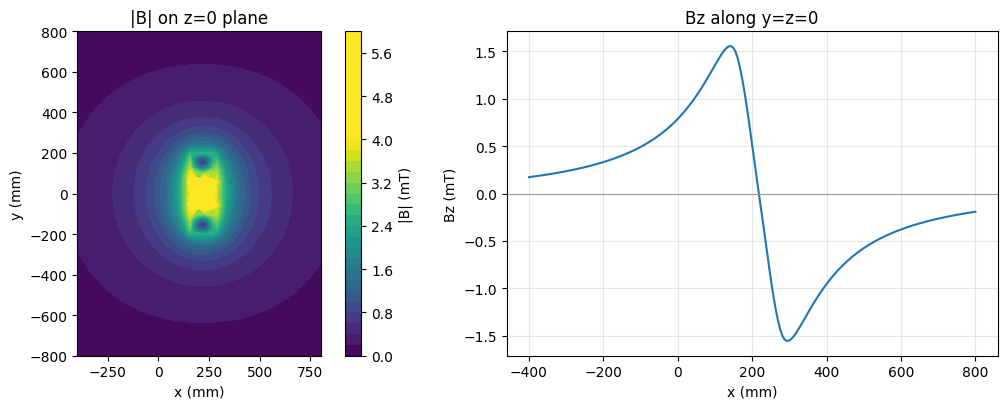


|B| range on z=0 plane: [0.09, 5.86] mT


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import radia as rad

coil, params = create_beam_steering_coil()
print("8-segment beam-steering coil:")
for k, v in params.items():
    print(f"  {k}: {v}")

# |B| on the z=0 plane above the conductor pack (the beam region).
nx, ny = 55, 70
xs = np.linspace(-0.40, 0.80, nx)
ys = np.linspace(-0.80, 0.80, ny)
Bmag = np.empty((ny, nx))
for j, y in enumerate(ys):
    for i, x in enumerate(xs):
        Bmag[j, i] = 1e3 * np.linalg.norm(rad.Fld(coil, "b", [x, y, 0.0]))  # mT

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2))
vmax = np.percentile(Bmag, 99)
pc = ax0.contourf(xs * 1e3, ys * 1e3, Bmag, levels=30, cmap="viridis", vmax=vmax)
fig.colorbar(pc, ax=ax0, label="|B| (mT)")
ax0.set_xlabel("x (mm)"); ax0.set_ylabel("y (mm)")
ax0.set_title("|B| on z=0 plane")
ax0.set_aspect("equal")

# Bz along the central x-axis (y=0, z=0).
xline = np.linspace(-0.40, 0.80, 200)
Bz = [1e3 * rad.Fld(coil, "b", [x, 0.0, 0.0])[2] for x in xline]
ax1.plot(xline * 1e3, Bz)
ax1.axhline(0, color="0.6", lw=0.8)
ax1.set_xlabel("x (mm)"); ax1.set_ylabel("Bz (mT)")
ax1.set_title("Bz along y=z=0")
ax1.grid(alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)

print(f"\n|B| range on z=0 plane: [{Bmag.min():.2f}, {Bmag.max():.2f}] mT")
rad.UtiDelAll()


## Durable JSON Record

The notebook writes a compact JSON record with runtime versions, source hashes, PVSM hash, and representative field-map statistics. `field_map.py` remains the full ParaView export helper and is archived beside the notebook.

In [3]:

from pathlib import Path
import datetime as _dt
import hashlib
import importlib.metadata as _metadata
import json
import platform
import sys

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'coil_model.py').exists():
    NOTEBOOK_DIR = Path('docs/complex_coil_geometry').resolve()


def _sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


def _version(name):
    try:
        return _metadata.version(name)
    except Exception:
        return None

source_files = ['coil_model.py', 'visualize_coils.py', 'field_map.py', 'README.md']
asset_files = ['complex_coil.pvsm']
result = {
    'schema': 'radia.docs.complex_coil_geometry.results.v1',
    'generated_at_utc': _dt.datetime.now(_dt.timezone.utc).isoformat(timespec='seconds').replace('+00:00', 'Z'),
    'versions': {
        'python_version': sys.version.split()[0],
        'python_executable': sys.executable,
        'platform': platform.platform(),
        'radia_version': _version('radia'),
        'numpy_version': _version('numpy'),
    },
    'topic_dir': 'docs/complex_coil_geometry',
    'coil_parameters': {
        'current_A': float(params['current']),
        'cross_section_width_m': float(params['cross_section']['width']),
        'cross_section_height_m': float(params['cross_section']['height']),
        'num_segments': int(params['num_segments']),
        'description': params['description'],
    },
    'field_slice': {
        'nx': int(nx),
        'ny': int(ny),
        'z_m': 0.0,
        'Bmag_mT_min': float(Bmag.min()),
        'Bmag_mT_max': float(Bmag.max()),
        'Bmag_mT_mean': float(Bmag.mean()),
    },
    'source_hashes': {
        name: _sha256(NOTEBOOK_DIR / name)
        for name in source_files
        if (NOTEBOOK_DIR / name).exists()
    },
    'asset_hashes': {
        name: {'sha256': _sha256(NOTEBOOK_DIR / name), 'bytes': (NOTEBOOK_DIR / name).stat().st_size}
        for name in asset_files
        if (NOTEBOOK_DIR / name).exists()
    },
    'checks': {
        'num_segments_is_8': int(params['num_segments']) == 8,
        'field_slice_positive': float(Bmag.max()) > 0.0,
        'pvsm_present': (NOTEBOOK_DIR / 'complex_coil.pvsm').exists(),
    },
}
assert all(result['checks'].values()), result['checks']
out = NOTEBOOK_DIR / 'complex_coil_results.json'
out.write_text(json.dumps(result, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print(f"wrote {out.relative_to(NOTEBOOK_DIR)}")
print(json.dumps(result['checks'], sort_keys=True))


wrote complex_coil_results.json
{"field_slice_positive": true, "num_segments_is_8": true, "pvsm_present": true}
